# Notebook — Teste do módulo `coordinates.py`

Este notebook testa o módulo:

```python
geodesy/coordinates.py
```

Serão testadas as transformações entre coordenadas geodésicas, ECEF, ENU e esféricas, além de conversões DMS e distância de Haversine.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")

import geodesy
from geodesy import coordinates
from geodesy import constants
from geodesy import ellipsoid

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Conversão geodésica para ECEF


In [2]:
# ============================================================
# 1. GEODÉSICA -> ECEF
# ============================================================

lat = -3.2
lon = -52.2
h = 100.0

X, Y, Z = coordinates.geodetic_to_ecef(lat, lon, h)

print("Latitude:", lat)
print("Longitude:", lon)
print("Altura:", h)
print("\nECEF:")
print("X =", X)
print("Y =", Y)
print("Z =", Z)

r = np.sqrt(X**2 + Y**2 + Z**2)
print("\nRaio geocêntrico do ponto:", r)


Latitude: -3.2
Longitude: -52.2
Altura: 100.0

ECEF:
X = 3903211.688895016
Y = -5031990.188336126
Z = -353663.02885195264

Raio geocêntrico do ponto: 6378170.919771157


## 2. Conversão ECEF para geodésica


In [3]:
# ============================================================
# 2. ECEF -> GEODÉSICA
# ============================================================

lat2, lon2, h2 = coordinates.ecef_to_geodetic(X, Y, Z)

print("Valores originais:")
print(lat, lon, h)

print("\nValores recuperados:")
print(lat2, lon2, h2)

print("\nDiferenças:")
print("dlat =", lat2 - lat)
print("dlon =", lon2 - lon)
print("dh =", h2 - h)


Valores originais:
-3.2 -52.2 100.0

Valores recuperados:
-3.2000000000000006 -52.2 100.0

Diferenças:
dlat = -4.440892098500626e-16
dlon = 0.0
dh = 0.0


## 3. Teste vetorial: vários pontos geodésicos


In [4]:
# ============================================================
# 3. TESTE VETORIAL
# ============================================================

lat_vec = np.array([-60, -30, 0, 30, 60], dtype=float)
lon_vec = np.array([-52, -52, -52, -52, -52], dtype=float)
h_vec = np.array([0, 100, 500, 1000, 2000], dtype=float)

Xv, Yv, Zv = coordinates.geodetic_to_ecef(lat_vec, lon_vec, h_vec)
lat_back, lon_back, h_back = coordinates.ecef_to_geodetic(Xv, Yv, Zv)

print("Latitudes originais:", lat_vec)
print("Latitudes recuperadas:", lat_back)

print("\nLongitudes originais:", lon_vec)
print("Longitudes recuperadas:", lon_back)

print("\nAlturas originais:", h_vec)
print("Alturas recuperadas:", h_back)

print("\nErro máximo em latitude:", np.max(np.abs(lat_back - lat_vec)))
print("Erro máximo em longitude:", np.max(np.abs(lon_back - lon_vec)))
print("Erro máximo em altura:", np.max(np.abs(h_back - h_vec)))


Latitudes originais: [-60. -30.   0.  30.  60.]
Latitudes recuperadas: [-60. -30.   0.  30.  60.]

Longitudes originais: [-52. -52. -52. -52. -52.]
Longitudes recuperadas: [-52. -52. -52. -52. -52.]

Alturas originais: [   0.  100.  500. 1000. 2000.]
Alturas recuperadas: [   0.          100.          500.         1000.         2000.00000001]

Erro máximo em latitude: 2.1316282072803006e-14
Erro máximo em longitude: 7.105427357601002e-15
Erro máximo em altura: 5.587935447692871e-09


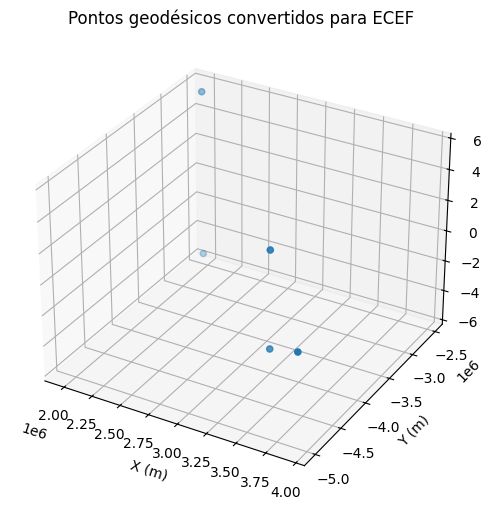

In [6]:
# Gráfico 3D simples dos pontos ECEF

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(Xv, Yv, Zv)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("Pontos geodésicos convertidos para ECEF")
plt.show()


## 4. Sistema local ENU


In [7]:
# ============================================================
# 4. CONVERSÃO GEODÉSICA -> ENU
# ============================================================

# Ponto de referência próximo de Altamira
lat0 = -3.2
lon0 = -52.2
h0 = 100.0

# Pontos próximos
lat_pts = np.array([-3.200, -3.199, -3.201, -3.200])
lon_pts = np.array([-52.200, -52.200, -52.200, -52.199])
h_pts = np.array([100.0, 100.0, 100.0, 120.0])

E, N, U = coordinates.geodetic_to_enu(lat_pts, lon_pts, h_pts, lat0, lon0, h0)

print("E:", E)
print("N:", N)
print("U:", U)


E: [0.00000000e+00 5.15313183e-10 2.86581033e-10 1.11149168e+02]
N: [ 0.00000000e+00  1.10579480e+02 -1.10579482e+02 -5.41446143e-05]
U: [ 0.00000000e+00 -9.64987039e-04 -9.64988104e-04  1.99990316e+01]


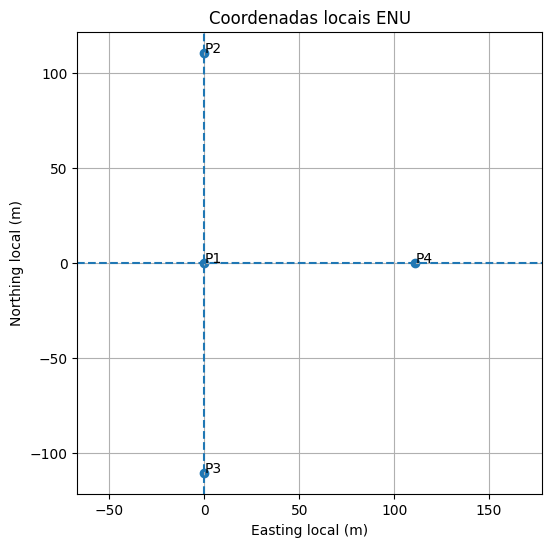

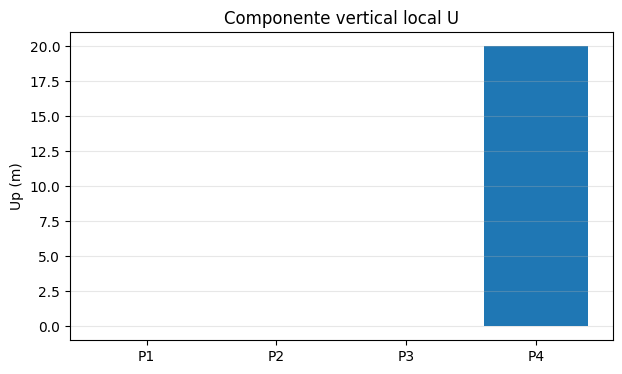

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(E, N)
for i in range(len(E)):
    plt.text(E[i], N[i], f"P{i+1}")
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Easting local (m)")
plt.ylabel("Northing local (m)")
plt.title("Coordenadas locais ENU")
plt.grid(True)
plt.axis("equal")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar([f"P{i+1}" for i in range(len(U))], U)
plt.ylabel("Up (m)")
plt.title("Componente vertical local U")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 5. Conversão ENU para ECEF e retorno para geodésica


In [9]:
# ============================================================
# 5. ENU -> ECEF -> GEODÉSICA
# ============================================================

X_enu, Y_enu, Z_enu = coordinates.enu_to_ecef(E, N, U, lat0, lon0, h0)
lat_enu, lon_enu, h_enu = coordinates.ecef_to_geodetic(X_enu, Y_enu, Z_enu)

print("Latitudes recuperadas:")
print(lat_enu)

print("\nLongitudes recuperadas:")
print(lon_enu)

print("\nAlturas recuperadas:")
print(h_enu)

print("\nComparação com os dados originais:")
for i in range(len(lat_pts)):
    print(f"P{i+1}:")
    print(" lat original/recuperada:", lat_pts[i], lat_enu[i])
    print(" lon original/recuperada:", lon_pts[i], lon_enu[i])
    print(" h original/recuperada:", h_pts[i], h_enu[i])


Latitudes recuperadas:
[-3.2   -3.199 -3.201 -3.2  ]

Longitudes recuperadas:
[-52.2   -52.2   -52.2   -52.199]

Alturas recuperadas:
[100. 100. 100. 120.]

Comparação com os dados originais:
P1:
 lat original/recuperada: -3.2 -3.2000000000000006
 lon original/recuperada: -52.2 -52.2
 h original/recuperada: 100.0 100.0
P2:
 lat original/recuperada: -3.199 -3.1990000000000003
 lon original/recuperada: -52.2 -52.2
 h original/recuperada: 100.0 100.0
P3:
 lat original/recuperada: -3.201 -3.2010000000000005
 lon original/recuperada: -52.2 -52.2
 h original/recuperada: 100.0 100.0
P4:
 lat original/recuperada: -3.2 -3.2000000000000006
 lon original/recuperada: -52.199 -52.199
 h original/recuperada: 120.0 120.0


## 6. Matriz de rotação ECEF para ENU


Matriz R ECEF -> ENU:
[[ 0.79015501  0.61290705  0.        ]
 [ 0.03421339 -0.04410764  0.99844076]
 [ 0.61195139 -0.78892297 -0.0558215 ]]

Teste de ortogonalidade R @ R.T:
[[ 1.00000000e+00 -5.01116530e-19 -2.55317575e-17]
 [-5.01116530e-19  1.00000000e+00  9.64891113e-18]
 [-2.55317575e-17  9.64891113e-18  1.00000000e+00]]


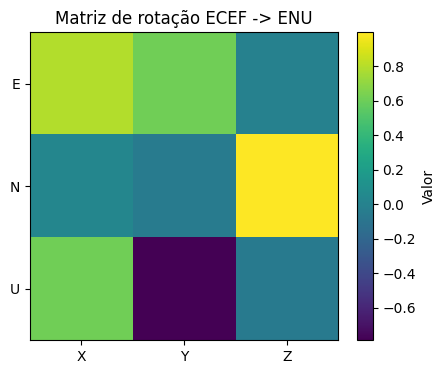

In [10]:
# ============================================================
# 6. MATRIZ DE ROTAÇÃO
# ============================================================

R = coordinates.rotation_ecef_to_enu(lat0, lon0)

print("Matriz R ECEF -> ENU:")
print(R)

print("\nTeste de ortogonalidade R @ R.T:")
print(R @ R.T)

plt.figure(figsize=(5, 4))
plt.imshow(R)
plt.colorbar(label="Valor")
plt.title("Matriz de rotação ECEF -> ENU")
plt.xticks([0, 1, 2], ["X", "Y", "Z"])
plt.yticks([0, 1, 2], ["E", "N", "U"])
plt.show()


## 7. Coordenadas esféricas geocêntricas


r: [6362132.2243971  6372924.41987247 6378637.         6373824.41607922
 6364132.21591204]
latitude geocêntrica: [-59.83307615 -29.83363842   0.          29.83366191  59.83312861]
longitude geocêntrica: [-52. -52. -52. -52. -52.]


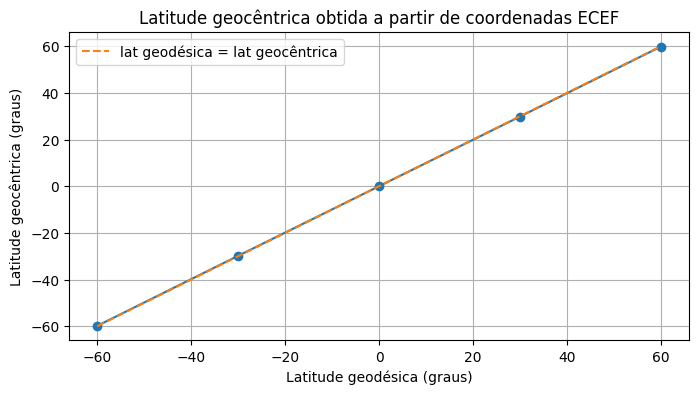

In [11]:
# ============================================================
# 7. GEODÉSICA -> ESFÉRICA GEOCÊNTRICA
# ============================================================

r, lat_gc, lon_gc = coordinates.geodetic_to_spherical(lat_vec, lon_vec, h_vec)

print("r:", r)
print("latitude geocêntrica:", lat_gc)
print("longitude geocêntrica:", lon_gc)

plt.figure(figsize=(8, 4))
plt.plot(lat_vec, lat_gc, marker="o")
plt.plot(lat_vec, lat_vec, linestyle="--", label="lat geodésica = lat geocêntrica")
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Latitude geocêntrica (graus)")
plt.title("Latitude geocêntrica obtida a partir de coordenadas ECEF")
plt.legend()
plt.grid(True)
plt.show()


## 8. Conversões DMS


In [12]:
# ============================================================
# 8. GRAUS DECIMAIS <-> DMS
# ============================================================

grau_decimal = -52.2063889
d, m, s = coordinates.degrees_to_dms(grau_decimal)
grau_retorno = coordinates.dms_to_degrees(d, m, s)

print("Grau decimal original:", grau_decimal)
print("DMS:", d, m, s)
print("Grau decimal recuperado:", grau_retorno)
print("Diferença:", grau_retorno - grau_decimal)


Grau decimal original: -52.2063889
DMS: -52.0 12.0 23.00004000000115
Grau decimal recuperado: -52.2063889
Diferença: 0.0


## 9. Distância de Haversine


In [13]:
# ============================================================
# 9. DISTÂNCIA DE HAVERSINE
# ============================================================

# Aproximação entre Altamira e Belém
lat_alt, lon_alt = -3.2, -52.2
lat_bel, lon_bel = -1.45, -48.50

dist = coordinates.haversine_distance(lat_alt, lon_alt, lat_bel, lon_bel)

print("Distância aproximada Altamira-Belém:")
print(dist/1000, "km")


Distância aproximada Altamira-Belém:
454.7986723477865 km


## 10. Mapa didático em coordenadas locais


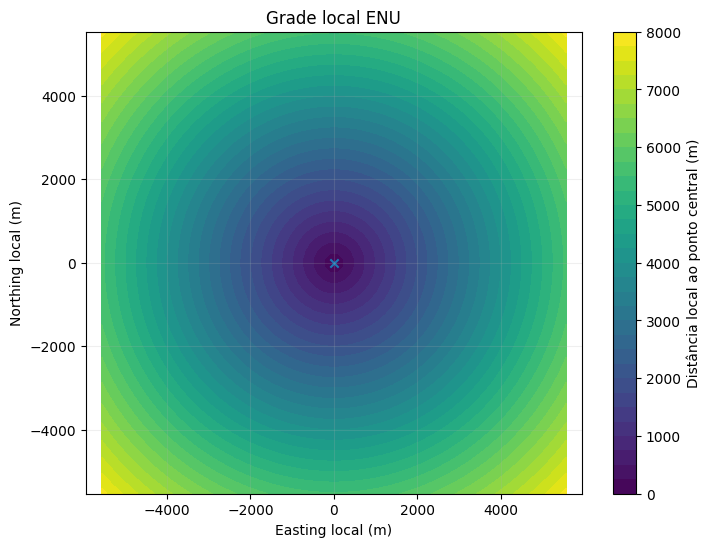

In [14]:
# ============================================================
# 10. GRADE LOCAL ENU A PARTIR DE LAT/LON
# ============================================================

lat_grid = np.linspace(lat0 - 0.05, lat0 + 0.05, 60)
lon_grid = np.linspace(lon0 - 0.05, lon0 + 0.05, 60)

LON, LAT = np.meshgrid(lon_grid, lat_grid)
H = np.zeros_like(LAT) + h0

E_grid, N_grid, U_grid = coordinates.geodetic_to_enu(LAT.ravel(), LON.ravel(), H.ravel(), lat0, lon0, h0)
E_grid = E_grid.reshape(LAT.shape)
N_grid = N_grid.reshape(LAT.shape)

dist_grid = np.sqrt(E_grid**2 + N_grid**2)

plt.figure(figsize=(8, 6))
c = plt.contourf(E_grid, N_grid, dist_grid, levels=30)
plt.colorbar(c, label="Distância local ao ponto central (m)")
plt.scatter([0], [0], marker="x")
plt.xlabel("Easting local (m)")
plt.ylabel("Northing local (m)")
plt.title("Grade local ENU")
plt.axis("equal")
plt.grid(alpha=0.2)
plt.show()


## 11. Resumo final


Se todas as células foram executadas sem erro, o módulo `coordinates.py` está funcionando corretamente.

O próximo notebook testará o módulo:

```python
geodesy/reference_frames.py
```
